In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import os

fifa_ranking_2022 = pd.read_csv('fifa_ranking_2022-10-06.csv')

fifa_ranking_2026 = pd.read_csv('fifa_ranking_2026-06-08.csv')

matches = pd.read_csv('matches_1930_2022.csv')

schedule_2026 = pd.read_csv('schedule_2026.csv')

world_cup = pd.read_csv('world_cup.csv')

print("Successfully loaded all datasets.")


Successfully loaded all datasets.


In [3]:
# Display the first few rows of each dataset
print("FIFA Ranking 2022:")
print(fifa_ranking_2022.head().to_string(index=False))

print("\nFIFA Ranking 2026:")
print(fifa_ranking_2026.head().to_string(index=False))

print("\nMatches 1930-2022:")
print(matches.head().to_string(index=False))

print("\nMatches 2026:")
print(schedule_2026.head().to_string(index=False))

print("\nWorld Cup History:")
print(world_cup.head().to_string(index=False))

FIFA Ranking 2022:
     team team_code association  rank  previous_rank  points  previous_points
   Brazil       BRA    CONMEBOL     1              1 1841.30          1837.56
  Belgium       BEL        UEFA     2              2 1816.71          1821.92
Argentina       ARG    CONMEBOL     3              3 1773.88          1770.65
   France       FRA        UEFA     4              4 1759.78          1764.85
  England       ENG        UEFA     5              5 1728.47          1737.46

FIFA Ranking 2026:
     team team_code association  rank  previous_rank      points  previous_points  rated_matches
Argentina       ARG    CONMEBOL     1              3 1876.118331      1874.814835             59
    Spain       ESP        UEFA     2              2 1873.013187      1876.395199             56
   France       FRA        UEFA     3              1 1869.428449      1877.322731             57
  England       ENG        UEFA     4              4 1827.048678      1825.965482             57
 Portuga

In [4]:
merge_ranking = pd.merge(fifa_ranking_2026, fifa_ranking_2022, on='team', suffixes=('_2026', '_2022'))

merge_ranking['rank_change'] = merge_ranking['rank_2022'] - merge_ranking['rank_2026']

# Display the merged ranking
print(merge_ranking[['team', 'rank_2022', 'rank_2026', 'rank_change']].head().to_string(index=False))

     team  rank_2022  rank_2026  rank_change
Argentina          3          1            2
    Spain          7          2            5
   France          4          3            1
  England          5          4            1
 Portugal          9          5            4


World Cup Data Head.
 Year         Host  Teams  Champion   Runner-Up                            TopScorrer  Attendance  AttendanceAvg  Matches
 2022        Qatar     32 Argentina      France                     Kylian Mbappé - 8     3404252          53191       64
 2018       Russia     32    France     Croatia                        Harry Kane - 6     3031768          47371       64
 2014       Brazil     32   Germany   Argentina                   James Rodríguez - 6     3429873          53592       64
 2010 South Africa     32     Spain Netherlands Wesley Sneijder, Thomas Müller... - 5     3178856          49670       64
 2006      Germany     32     Italy      France                    Miroslav Klose - 5     3352605          52384       64

World Cup Champions Frequency
Champion
Brazil          5
Italy           4
Argentina       3
France          2
Germany         2
West Germany    2
Uruguay         2
Spain           1
England         1
Name: count, dtype: int64


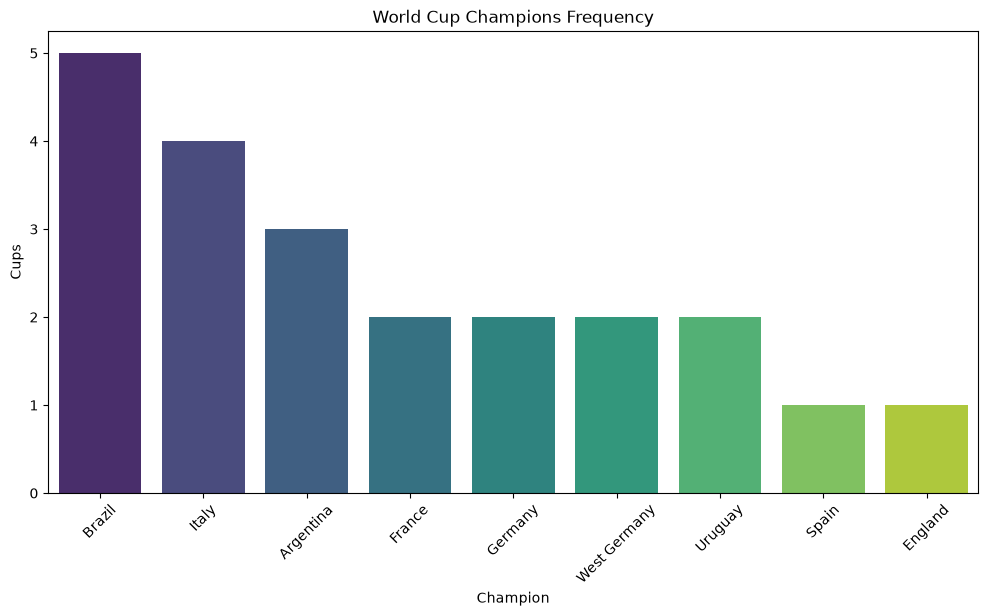

In [17]:
# World Cup summary
print('World Cup Data Head.')
print(world_cup.head().to_string(index=False))

# Display Championship
champion_counts = world_cup['Champion'].value_counts()
print("\nWorld Cup Champions Frequency")
print(champion_counts)

plt.figure(figsize=(12, 6))
sns.barplot(x=champion_counts.index, y=champion_counts.values, hue=champion_counts.index, palette='viridis', legend=False)
plt.title('World Cup Champions Frequency')
plt.xticks(rotation=45)
plt.xlabel('Champion')
plt.ylabel('Cups')
plt.show()